# Credit Scoring Model

## CodeAlpha Machine Learning Internship

### Task 1

## Project Description

This project is developed as part of the CodeAlpha Machine Learning Internship.

The objective of this project is to build a Credit Scoring Model using Machine Learning. The model predicts whether a loan application is likely to be approved based on applicant information such as income, education, credit history, loan amount, and property area.

The project includes:
- Data preprocessing
- Missing value handling
- Feature encoding
- Data visualization
- Model training using Logistic Regression
- Model evaluation
- Prediction for new applicants

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

# Show the first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
# Number of rows and columns
df.shape

(614, 13)

In [3]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
# Count missing values in every column
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [6]:
# Fill missing values in categorical (text) columns
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

# Fill missing values in numerical columns
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [7]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [8]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Convert text columns into numbers
columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in columns:
    df[col] = le.fit_transform(df[col])

# Display first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [9]:
# Features (Input)
X = df.drop(["Loan_ID", "Loan_Status"], axis=1)

# Target (Output)
y = df["Loan_Status"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  
0              2  
1              0  
2              2  
3              2  
4      

In [10]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 11)
Testing data: (123, 11)


In [11]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Print evaluation metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


Confusion Matrix:

[[18 25]
 [ 1 79]]


In [15]:
import pandas as pd

new_applicant = pd.DataFrame({
    "Gender": [1],
    "Married": [1],
    "Dependents": [1],
    "Education": [0],
    "Self_Employed": [0],
    "ApplicantIncome": [7000],
    "CoapplicantIncome": [2000],
    "LoanAmount": [150],
    "Loan_Amount_Term": [360],
    "Credit_History": [1],
    "Property_Area": [2]
})

prediction = model.predict(new_applicant)

if prediction[0] == 1:
    print("Prediction: Loan Approved ✅")
else:
    print("Prediction: Loan Rejected ❌")

Prediction: Loan Approved ✅


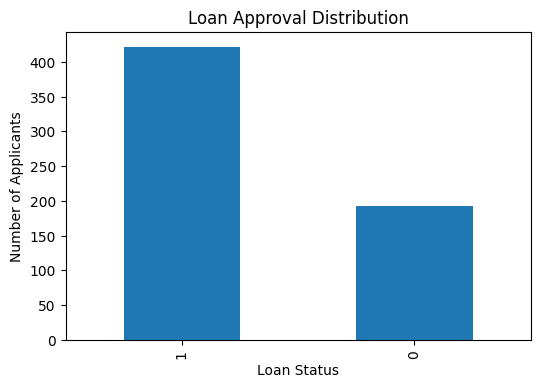

In [22]:
import matplotlib.pyplot as plt

# Count loan approval values
loan_status = df["Loan_Status"].value_counts()

# Create bar chart
plt.figure(figsize=(6,4))
loan_status.plot(kind="bar")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

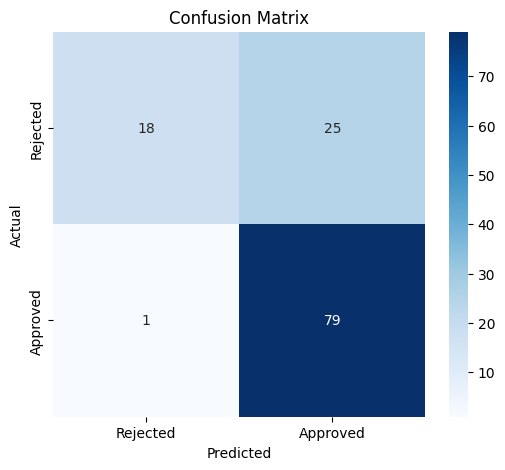

In [21]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

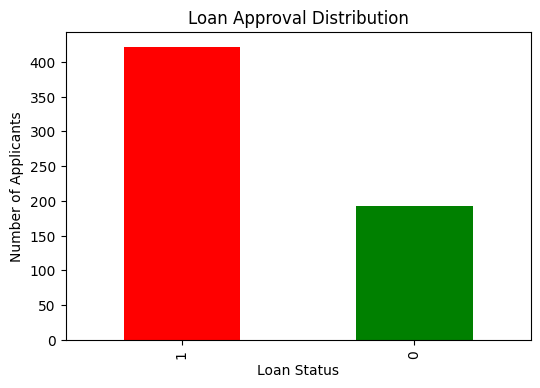

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Loan_Status"].value_counts().plot(
    kind="bar",
    color=["red","green"]
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

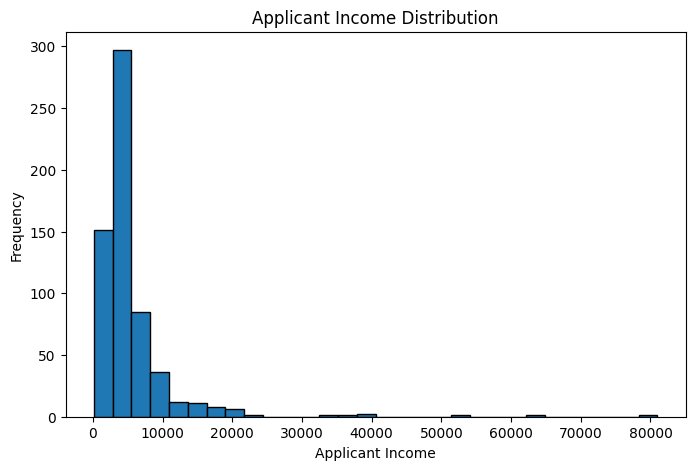

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    df["ApplicantIncome"],
    bins=30,
    edgecolor="black"
)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

In [25]:
import seaborn as sns

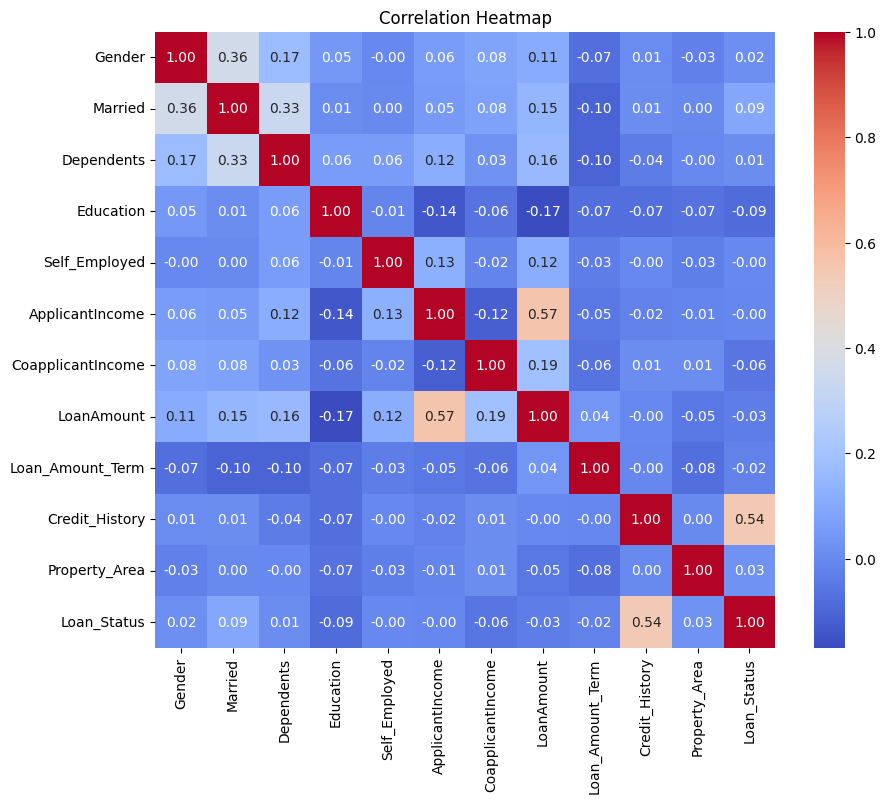

In [26]:
plt.figure(figsize=(10,8))

corr = df.drop(columns=["Loan_ID"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
from sklearn.metrics import confusion_matrix

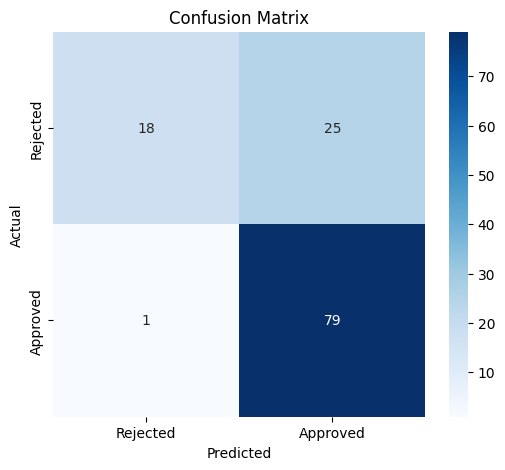

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected","Approved"],
    yticklabels=["Rejected","Approved"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

In [30]:
# Get prediction probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.7531976744186046


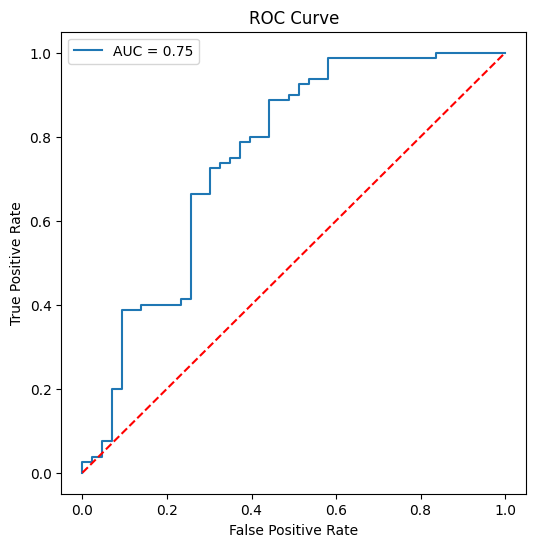

In [31]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [32]:
import joblib

In [33]:
joblib.dump(model, "credit_scoring_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Conclusion

This project successfully demonstrates the implementation of a Credit Scoring Model using Machine Learning.

The dataset was preprocessed, cleaned, and visualized before training a Logistic Regression model. The model was evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix. Finally, the trained model was saved for future predictions.

This project helped me understand the complete Machine Learning workflow from data preprocessing to model evaluation and deployment.